In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [2]:
# Functions
class PerceptronScratch:
    def __init__(self, learning_rate=0.1, n_epochs=10):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = None
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for _ in range(self.n_epochs):
            for idx, x_i in enumerate(X):
                # Forward pass: z = w^T * x + b
                linear_output = np.dot(x_i, self.weights) + self.bias
                
                # Activation: Heaviside step function
                y_predicted = np.where(linear_output >= 0, 1, 0)
                
                # Learning mechanism: update weights and bias
                update = self.lr * (y[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update
                
    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, 0)

def plot_decision_boundary(model, ax, title, accuracy):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='winter')
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='winter', edgecolors='k', s=50)
    ax.set_title(f"{title}\nTest Accuracy: {accuracy * 100:.1f}%")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

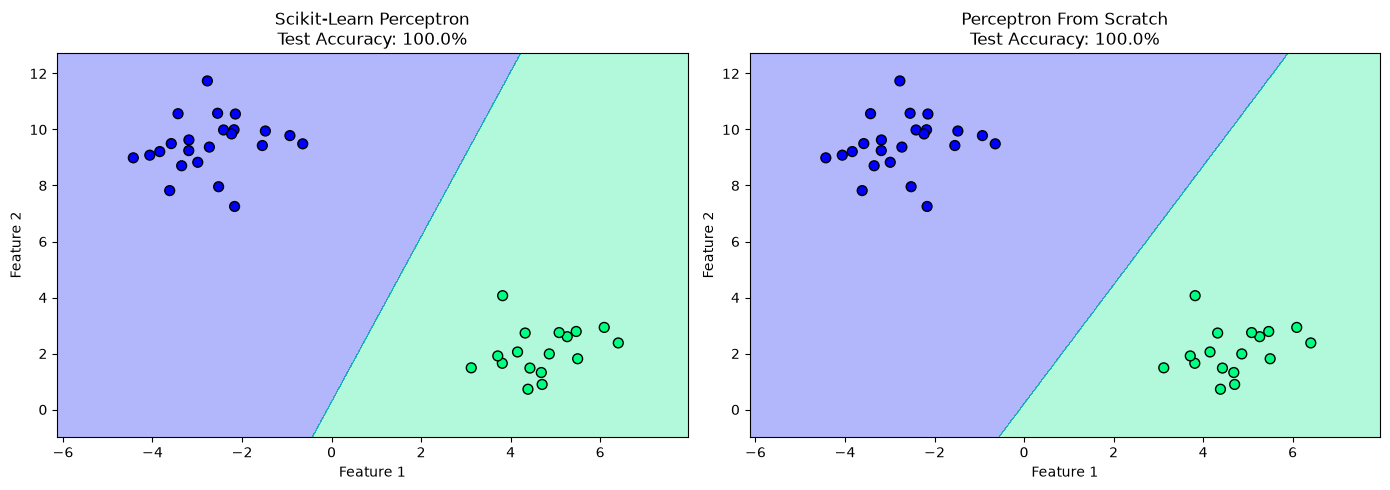

In [ ]:
# Data generation
X, y = make_blobs(n_samples=200, centers=2, n_features=2, random_state=42, cluster_std=1.0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scikit-Learn Perceptron Implementation
clf_sklearn = Perceptron(eta0=0.1, max_iter=10, random_state=42)
clf_sklearn.fit(X_train, y_train)
y_pred_sklearn = clf_sklearn.predict(X_test)
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)

clf_scratch = PerceptronScratch(learning_rate=0.1, n_epochs=10)
clf_scratch.fit(X_train, y_train)
y_pred_scratch = clf_scratch.predict(X_test)
acc_scratch = accuracy_score(y_test, y_pred_scratch)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_decision_boundary(clf_sklearn, axes[0], "Scikit-Learn Perceptron", acc_sklearn)
plot_decision_boundary(clf_scratch, axes[1], "Perceptron From Scratch", acc_scratch)

plt.tight_layout()
plt.show()